# 03 — Feature Importance, Feature Reduction and Class-Imbalance Analysis

Executed feature-analysis notebook using the selected pre-call hyperparameters produced by Workflow 02.

## 1. Feature importance

Feature evidence is compared using direct target association, grouped Logistic Regression coefficient magnitude and held-out HGB permutation importance.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 180)

ROOT = Path(".")
R = ROOT / "results" / "features_imbalance"
F = ROOT / "figures" / "features_imbalance"

importance = pd.read_csv(R / "importance_comparison.csv")
display(importance.sort_values("hgb_rank").round(4))

/home/oai/.config/matplotlib is not a writable directory


Matplotlib created a temporary cache directory at /tmp/matplotlib-57l6ciqj because there was an issue with the default path (/home/oai/.config/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


,feature,association_strength,association_rank,lr_importance,lr_rank,hgb_permutation,hgb_rank
11,month,0.1945,1,0.9579,1,0.1478,1
10,contact,0.0896,2,0.4748,2,0.1051,2
2,day,0.0064,11,0.1263,10,0.0559,3
8,housing,0.0541,5,0.3444,5,0.0348,4
0,age,0.0203,10,0.0388,12,0.0144,5
5,marital,0.0579,4,0.2296,6,0.0085,6
1,balance,0.0302,9,0.0569,11,0.0077,7
3,campaign,0.0404,7,0.1632,8,0.0030,8
6,education,0.0484,6,0.1964,7,0.0024,9
9,loan,0.0306,8,0.3444,3,0.0010,10


## 2. Selected Top-3, Top-4 and Top-5 feature sets

In [2]:
sets = json.loads((R / "selected_feature_sets.json").read_text())
for name, features in sets.items():
    print(f"{name}: {features}")

Top 3: ['month', 'contact', 'day']
Top 4: ['month', 'contact', 'day', 'housing']
Top 5: ['month', 'contact', 'day', 'housing', 'age']
All 12: ['age', 'balance', 'day', 'campaign', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month']


## 3. Feature-reduction experiment

In [3]:
reduction = pd.read_csv(R / "feature_reduction.csv")
display(reduction[[
    "model", "feature_set", "n_features", "n_rows", "base_rate",
    "accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc"
]].round(4))

,model,feature_set,n_features,n_rows,base_rate,accuracy,precision,recall,f1,roc_auc,pr_auc
0,LR,Top 3,3,40000,0.0724,0.9276,0.4967,0.0259,0.0492,0.6673,0.1953
1,LR,Top 4,4,40000,0.0724,0.9279,0.5306,0.0359,0.0673,0.6728,0.2122
2,LR,Top 5,5,40000,0.0724,0.9277,0.5137,0.0325,0.0611,0.6738,0.2103
3,LR,All 12,12,40000,0.0724,0.9278,0.5246,0.0331,0.0624,0.6848,0.2154
4,HGB,Top 3,3,40000,0.0724,0.9285,0.5625,0.0559,0.1018,0.7036,0.2439
5,HGB,Top 4,4,40000,0.0724,0.9283,0.5455,0.0559,0.1015,0.7062,0.2463
6,HGB,Top 5,5,40000,0.0724,0.9276,0.5024,0.0356,0.0664,0.7072,0.2446
7,HGB,All 12,12,40000,0.0724,0.9276,0.5086,0.0204,0.0392,0.7153,0.2447


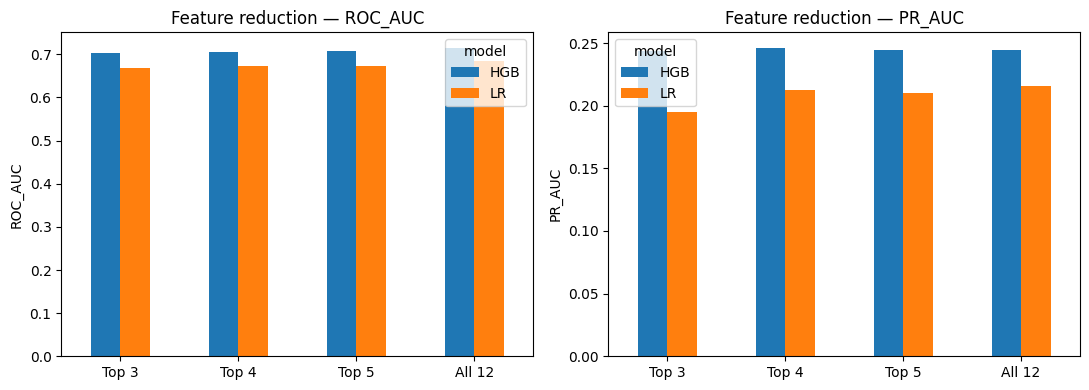

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
order = ["Top 3", "Top 4", "Top 5", "All 12"]
for ax, metric in zip(axes, ["roc_auc", "pr_auc"]):
    p = reduction.pivot(index="feature_set", columns="model", values=metric).reindex(order)
    p.plot(kind="bar", ax=ax)
    ax.set_title(f"Feature reduction — {metric.upper()}")
    ax.set_xlabel("")
    ax.set_ylabel(metric.upper())
    ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

## 4. Partial-dependence diagnostics

month


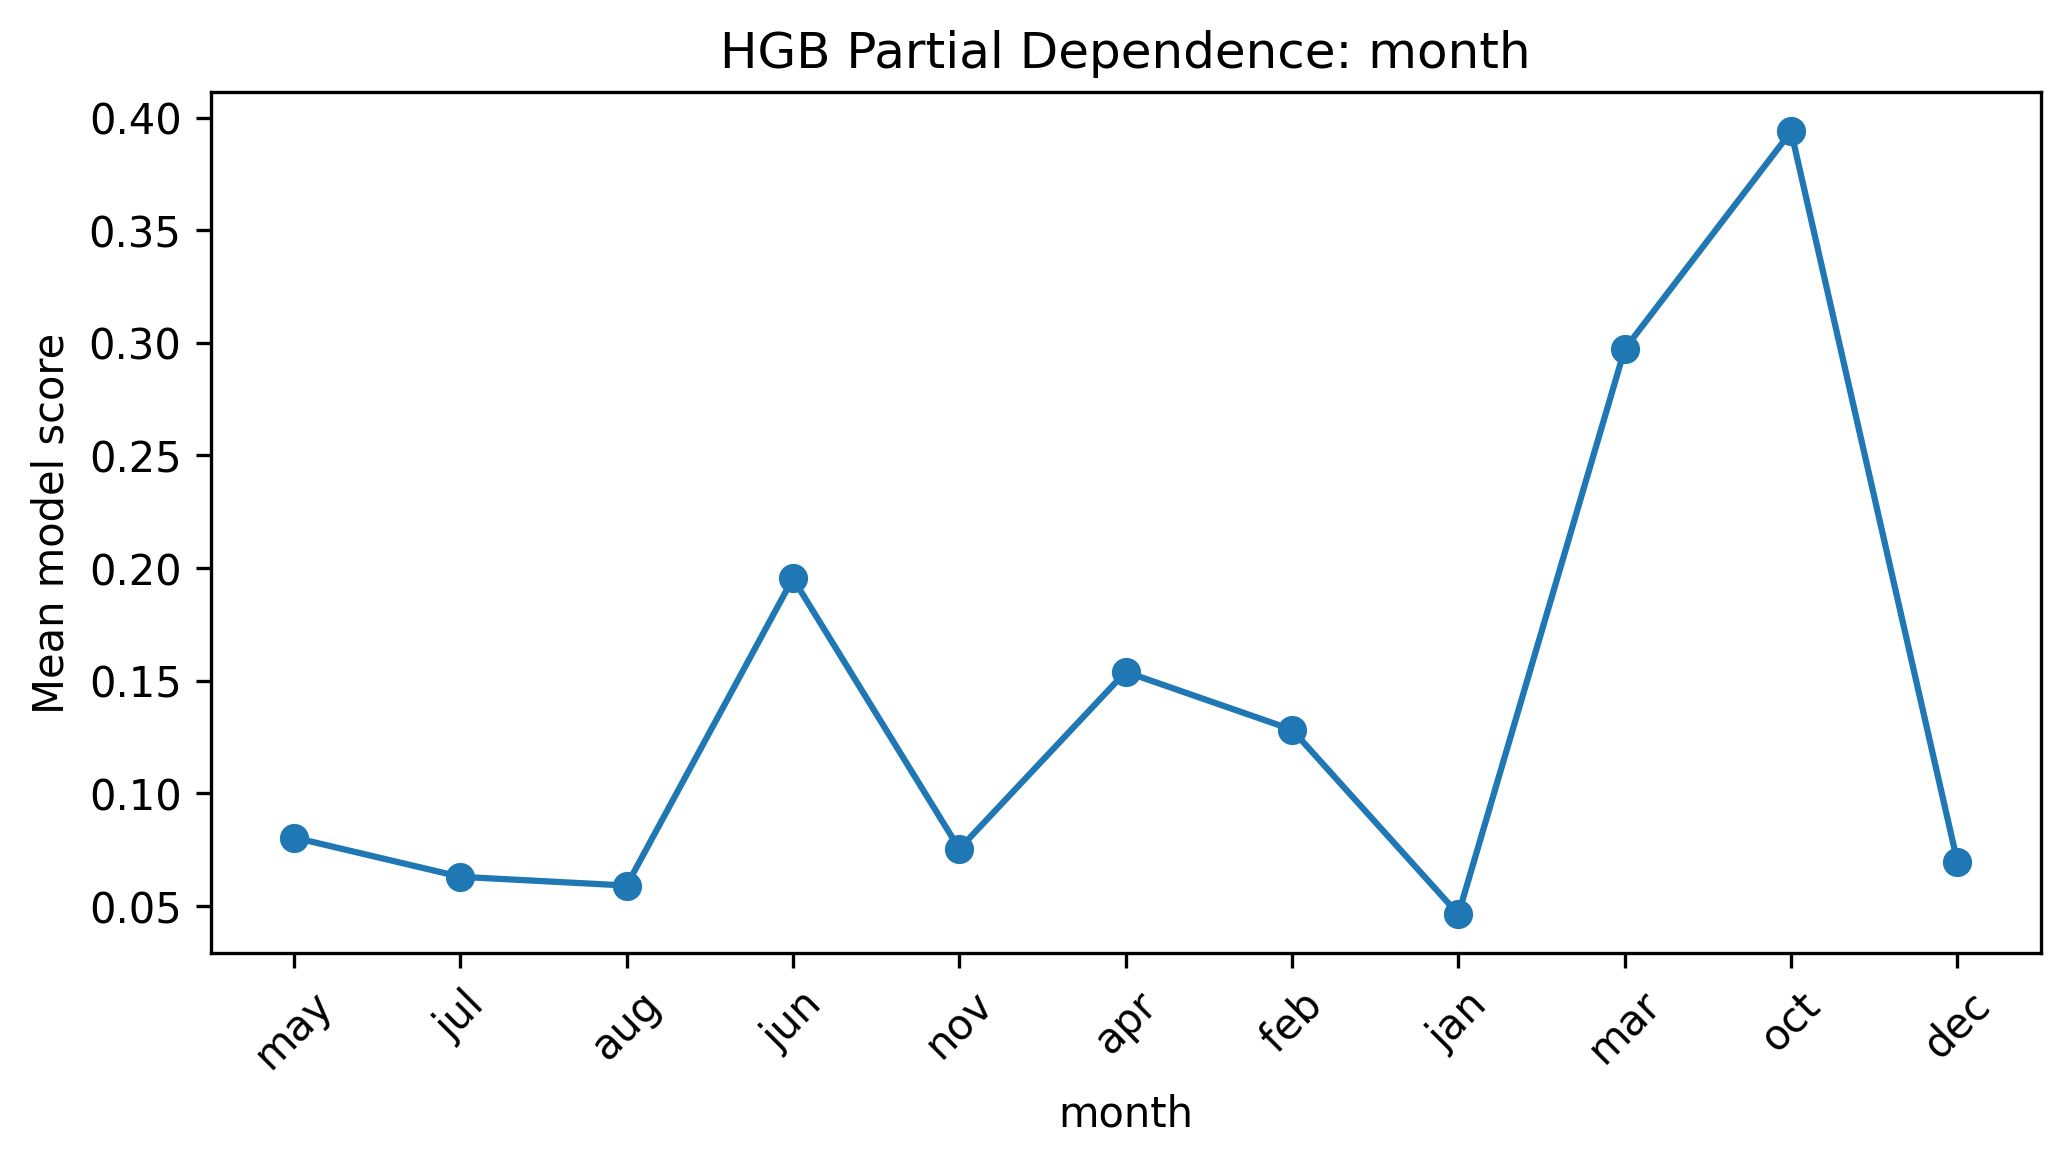

contact


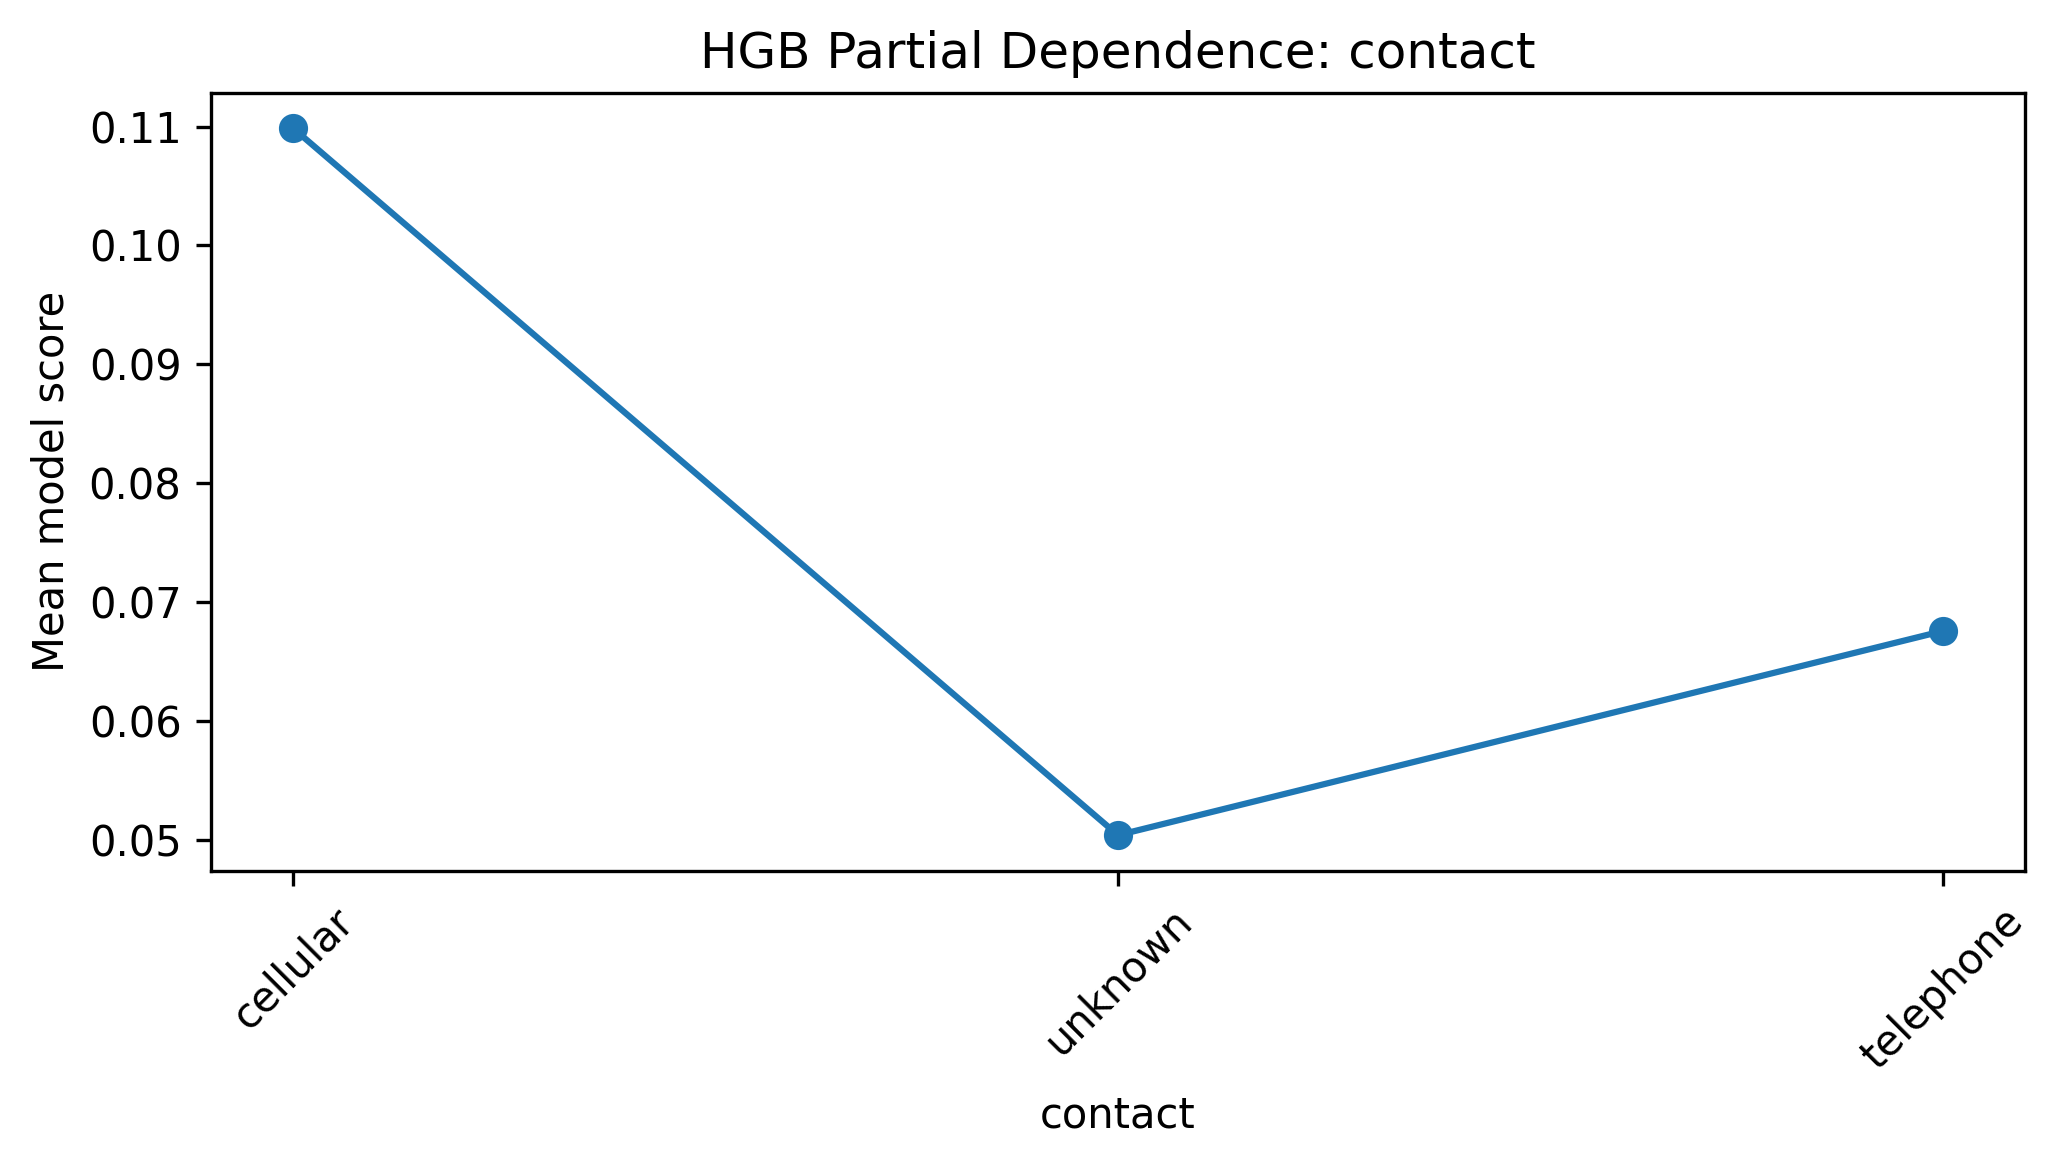

day


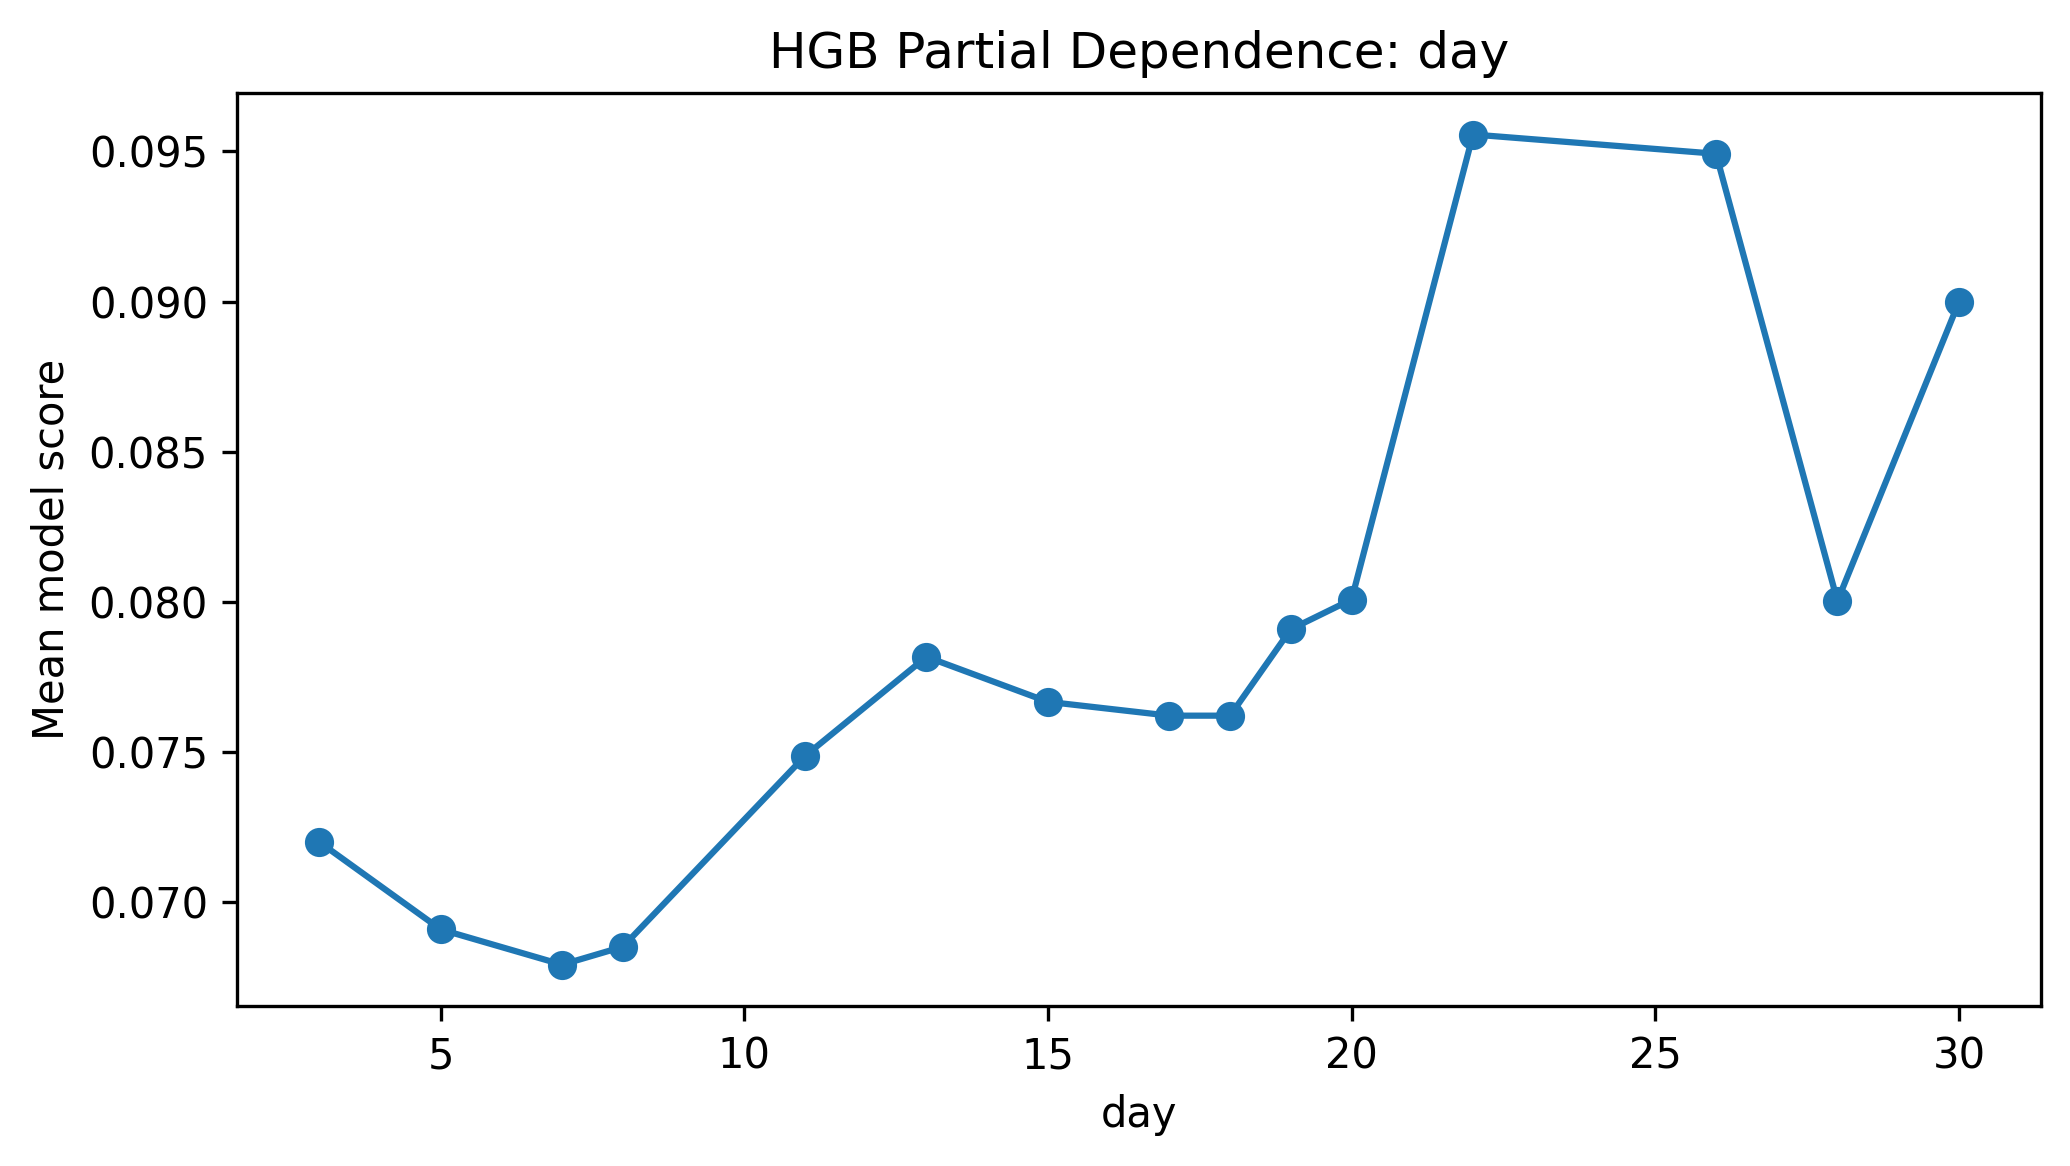

housing


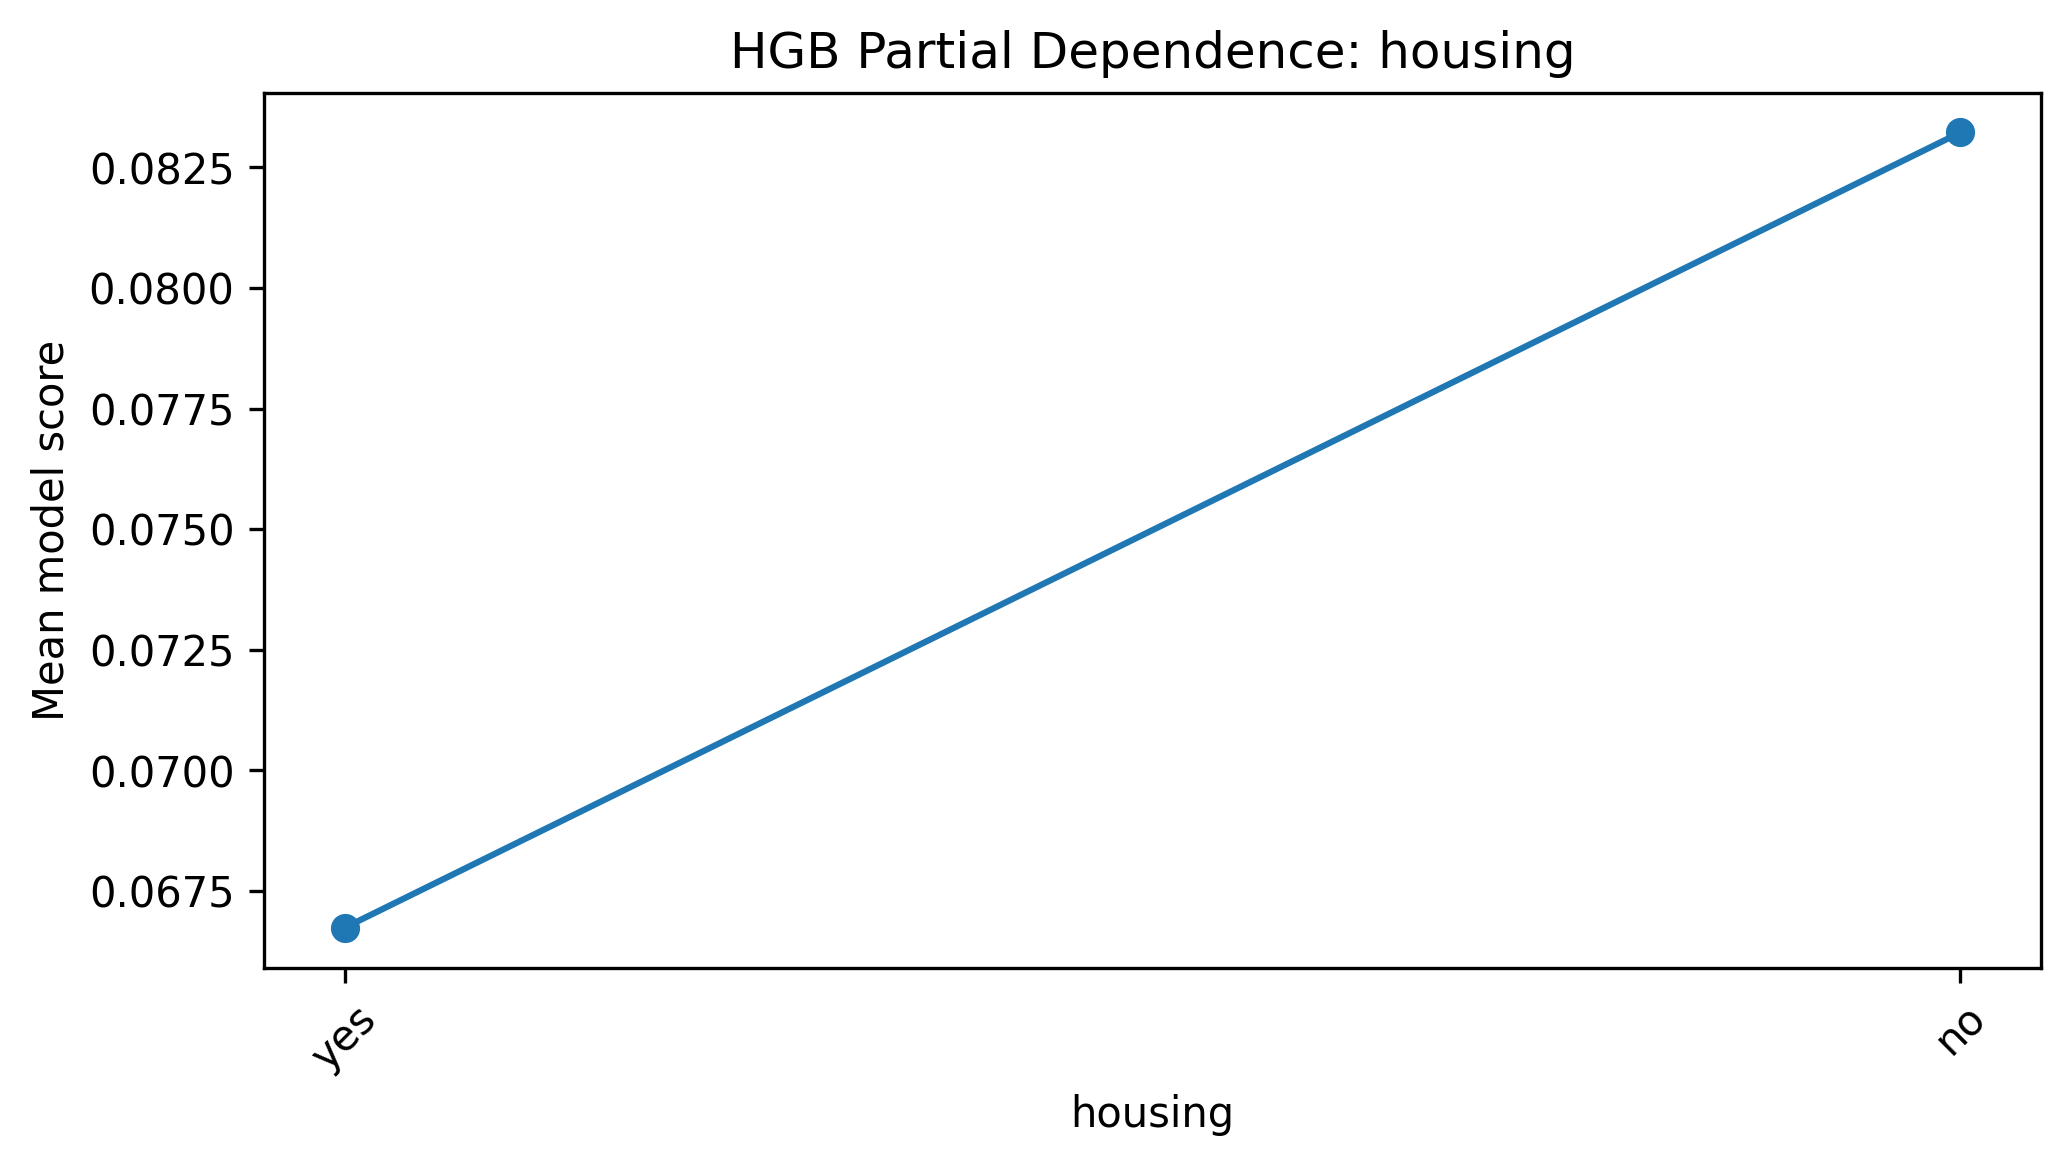

age


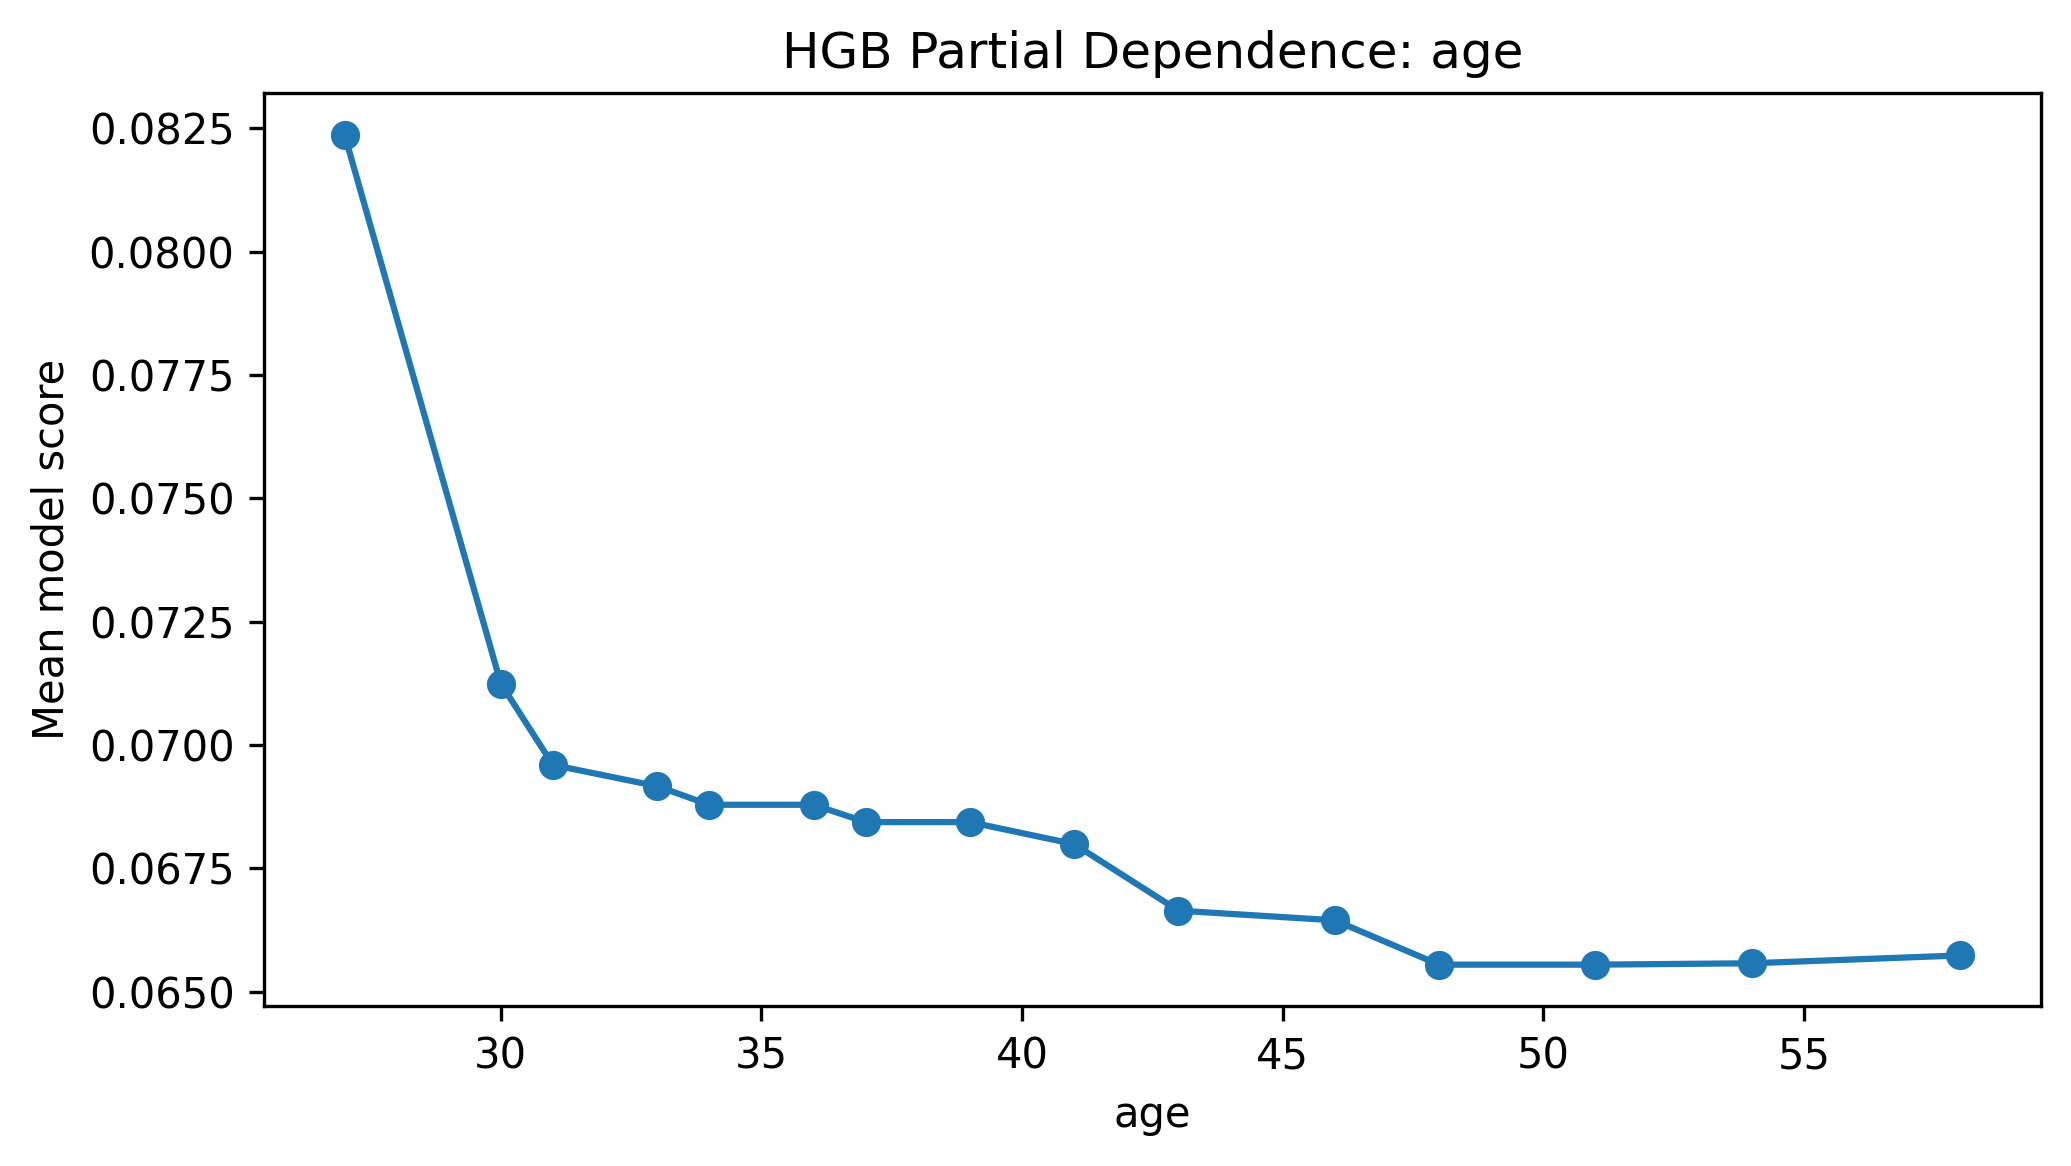

In [5]:
for feature in ["month", "contact", "day", "housing", "age"]:
    path = F / f"partial_dependence_{feature}.png"
    if path.exists():
        print(feature)
        display(Image(filename=str(path)))

Partial-dependence plots are interpreted descriptively. Because marginal PDP changes one feature while holding the others at observed values, some synthetic combinations can be implausible.

## 5. Class-imbalance experiments

In [6]:
imb = pd.read_csv(R / "class_imbalance.csv")
display(imb[[
    "model", "strategy", "n_rows", "base_rate",
    "accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc"
]].round(4))

,model,strategy,n_rows,base_rate,accuracy,precision,recall,f1,roc_auc,pr_auc
0,HGB,none,40000,0.0724,0.9276,0.5086,0.0204,0.0392,0.7153,0.2447
1,HGB,class_weight,40000,0.0724,0.7455,0.1516,0.5473,0.2374,0.7168,0.2468
2,HGB,oversampling,40000,0.0724,0.7507,0.1557,0.5521,0.2428,0.7191,0.2505
3,HGB,undersampling,40000,0.0724,0.7234,0.1449,0.5753,0.2315,0.7114,0.2342
4,HGB,SMOTENC,40000,0.0724,0.9202,0.3975,0.1989,0.2651,0.6844,0.2149
5,HGB,threshold_tuning,40000,0.0724,0.9176,0.3981,0.2704,0.3220,0.7153,0.2447
6,LR,none,40000,0.0724,0.9278,0.5246,0.0331,0.0624,0.6848,0.2154
7,LR,class_weight,40000,0.0724,0.6607,0.1236,0.6053,0.2053,0.6875,0.2097
8,LR,oversampling,40000,0.0724,0.6620,0.1243,0.6067,0.2063,0.6881,0.2087
9,LR,undersampling,40000,0.0724,0.6587,0.1224,0.6019,0.2034,0.6861,0.2070


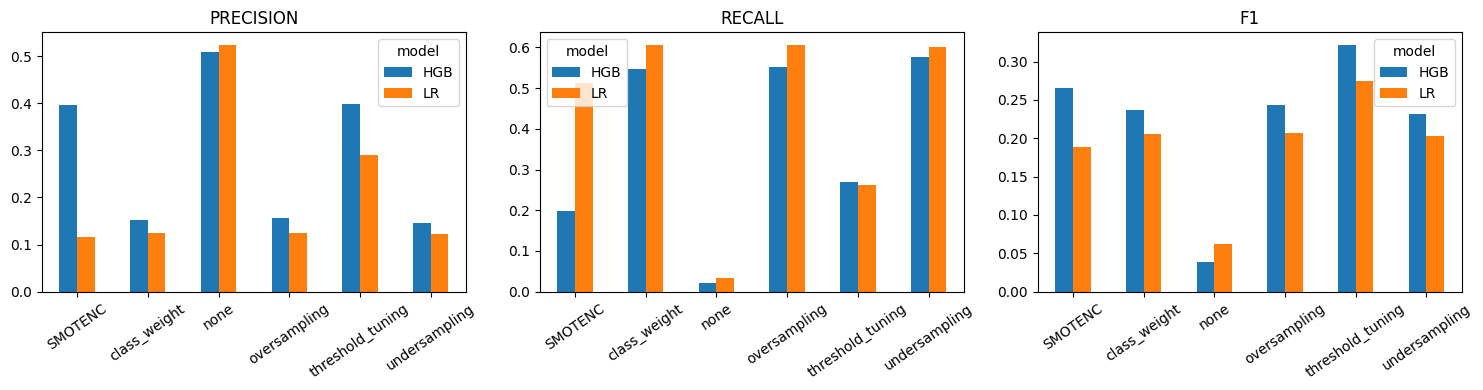

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, metric in zip(axes, ["precision", "recall", "f1"]):
    p = imb.pivot(index="strategy", columns="model", values=metric)
    p.plot(kind="bar", ax=ax)
    ax.set_title(metric.upper())
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=35)
plt.tight_layout()
plt.show()

## 6. Pseudo-group sensitivity and limitations

In [8]:
grouped = pd.read_csv(R / "unweighted_pseudo_group_sensitivity.csv")
limits = pd.read_csv(R / "analysis_limitations.csv")
display(grouped.round(4))
display(limits)

,model,validation,selection_note,n_rows,base_rate,accuracy,precision,recall,f1,roc_auc,pr_auc,tn,fp,fn,tp
0,LR,pseudo_group_5fold_sensitivity,pseudo-ID based on age+job+marital+education+b...,40000,0.0724,0.9277,0.5135,0.0328,0.0617,0.6850,0.2157,37014,90,2801,95
1,HGB,pseudo_group_5fold_sensitivity,pseudo-ID based on age+job+marital+education+b...,40000,0.0724,0.9280,0.5606,0.0256,0.0489,0.7151,0.2444,37046,58,2822,74


,item,status
0,resampling_hyperparameters,"controlled fixed-capacity comparison, not sepa..."
1,partial_dependence,marginal PDP may create implausible feature co...
2,customer_identity,"pseudo-group sensitivity added, but no true cu..."
